In [1]:
import os

# Define explicit, clean directory paths for our modular architecture
folders = [
    "src",
    "tests",
    "data/raw",
    "outputs/csv",
    "outputs/images",
    "outputs/reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"📁 Initialized directory path: {folder}")

📁 Initialized directory path: src
📁 Initialized directory path: tests
📁 Initialized directory path: data/raw
📁 Initialized directory path: outputs/csv
📁 Initialized directory path: outputs/images
📁 Initialized directory path: outputs/reports


In [2]:
config_content = """data:
  stream_url: "https://raw.githubusercontent.com/Arham-Aalam/ML-progress/master/amazon_co-ecommerce_sample.csv"
  raw_path: "data/raw/amazon_ecommerce_raw.csv"
  output_csv: "outputs/csv/segment_output.csv"
  output_summary: "outputs/reports/cluster_summary.csv"
  output_img_dir: "outputs/images/"

pipeline:
  rolling_months: 12
  random_state: 42
  max_k: 6

features:
  clustering_cols:
    - "Recency_Days"
    - "Frequency"
    - "Monetary"
    - "Average_Sentiment"
"""

with open("config.yaml", "w") as f:
    f.write(config_content)
print("💾 Saved configuration matrix: config.yaml")

💾 Saved configuration matrix: config.yaml


In [3]:
preprocessing_content = """import os
import pandas as pd
import numpy as np
from datetime import datetime
import logging

logger = logging.getLogger("Pipeline")

class DataPreprocessor:
    def __init__(self, config: dict):
        self.config = config
        self.raw_df = pd.DataFrame()

    def load_data(self) -> pd.DataFrame:
        url = self.config['data']['stream_url']
        logger.info(f"Downloading data from: {url}")
        self.raw_df = pd.read_csv(url, on_bad_lines='skip')
        os.makedirs(os.path.dirname(self.config['data']['raw_path']), exist_ok=True)
        self.raw_df.to_csv(self.config['data']['raw_path'], index=False)
        return self.raw_df

    def _clean_price(self, val) -> float:
        try:
            return float(str(val).split('-')[0].replace('£','').replace('$','').strip())
        except:
            return np.nan

    def _extract_rating(self, val) -> float:
        try:
            if 'out of 5 stars' in str(val):
                return float(str(val).split('out of 5 stars')[0].split('//')[-1].strip())
            return np.nan
        except:
            return np.nan

    def _parse_dates(self, val):
        try:
            date_str = str(val).split('//')[0].replace('on', '').strip()
            date_str = date_str.replace('Nov.', 'November').replace('Dec.', 'December')
            for fmt in ('%d %B %Y', '%d %b %Y', '%B %d, %Y'):
                try:
                    return datetime.strptime(date_str, fmt)
                except ValueError:
                    continue
            return pd.NaT
        except:
            return pd.NaT

    def clean_and_filter(self) -> pd.DataFrame:
        if self.raw_df.empty:
            raise ValueError("Raw dataset is empty.")
        df = self.raw_df.copy()
        df['Price'] = df['price'].apply(self._clean_price)
        df['Star_Rating'] = df['customer_reviews'].apply(self._extract_rating)
        df['Review_Date'] = df['customer_reviews'].apply(self._parse_dates)
        df['Review_Text'] = df['customer_reviews'].astype(str).str.strip()

        df['Price'] = df['Price'].fillna(df['Price'].median() if not df['Price'].isnull().all() else 49.99)
        df['Star_Rating'] = df['Star_Rating'].fillna(4.0)

        valid_dates = df['Review_Date'].dropna()
        if not valid_dates.empty:
            max_date = valid_dates.max()
            start_date = max_date - pd.DateOffset(months=self.config['pipeline']['rolling_months'])
            df = df[(df['Review_Date'] >= start_date) & (df['Review_Date'] <= max_date)].copy()
            logger.info(f"Timeline synchronized: {start_date.date()} to {max_date.date()}")

        df = df.rename(columns={'uniq_id': 'User_ID'})
        return df

    def aggregate_customers(self, df: pd.DataFrame) -> pd.DataFrame:
        max_date = df['Review_Date'].max() if 'Review_Date' in df.columns and not df['Review_Date'].isnull().all() else datetime.now()
        df['Recency_Days'] = df['Review_Date'].apply(lambda x: (max_date - x).days if pd.notnull(x) else 0)

        customer_df = df.groupby("User_ID").agg({
            "Recency_Days": "min",
            "price": "count",
            "Price": "sum",
            "Star_Rating": "mean"
        }).rename(columns={
            "price": "Frequency",
            "Price": "Monetary",
            "Star_Rating": "Average_Rating"
        })

        text_mapping = df.groupby("User_ID")["Review_Text"].apply(lambda x: " ".join(x)).to_dict()
        customer_df["Aggregated_Reviews"] = customer_df.index.map(text_mapping)
        return customer_df.reset_index()
"""

with open("src/preprocessing.py", "w") as f:
    f.write(preprocessing_content)
print("💾 Saved preprocessing module: src/preprocessing.py")

💾 Saved preprocessing module: src/preprocessing.py


In [4]:
sentiment_content = """import pandas as pd
from textblob import TextBlob

class SentimentAnalyzer:
    def calculate_sentiment(self, customer_df: pd.DataFrame) -> pd.DataFrame:
        customer_df['Average_Sentiment'] = customer_df['Aggregated_Reviews'].apply(
            lambda text: TextBlob(str(text)).sentiment.polarity if str(text).strip() else 0.0
        )
        customer_df['Sentiment_Label'] = customer_df['Average_Sentiment'].apply(
            lambda s: "Positive" if s > 0.05 else ("Negative" if s < -0.05 else "Neutral")
        )
        return customer_df
"""

with open("src/sentiment.py", "w") as f:
    f.write(sentiment_content)
print("💾 Saved NLP sentiment engine: src/sentiment.py")

💾 Saved NLP sentiment engine: src/sentiment.py


In [5]:
clustering_content = """import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import logging

logger = logging.getLogger("Pipeline")

class CustomerSegmenter:
    def __init__(self, config: dict):
        self.config = config
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=2)
        self.best_k = 3
        self.elbow_scores = []
        self.silhouette_scores = {}

    def find_best_k(self, df: pd.DataFrame) -> int:
        features = self.config['features']['clustering_cols']
        scaled_data = self.scaler.fit_transform(df[features])
        max_k = self.config['pipeline']['max_k']

        for k in range(2, max_k + 1):
            km = KMeans(n_clusters=k, random_state=self.config['pipeline']['random_state'], n_init=10)
            labels = km.fit_predict(scaled_data)
            self.elbow_scores.append(km.inertia_)
            self.silhouette_scores[k] = silhouette_score(scaled_data, labels)

        self.best_k = max(self.silhouette_scores, key=self.silhouette_scores.get)
        logger.info(f"Optimal cluster K selected: K={self.best_k}")
        return self.best_k

    def fit_clusters(self, df: pd.DataFrame) -> pd.DataFrame:
        features = self.config['features']['clustering_cols']
        scaled_features = self.scaler.fit_transform(df[features])

        km = KMeans(n_clusters=self.best_k, random_state=self.config['pipeline']['random_state'], n_init=10)
        df['Cluster_ID'] = km.fit_predict(scaled_features)

        pca_coords = self.pca.fit_transform(scaled_features)
        df['PCA_1'] = pca_coords[:, 0]
        df['PCA_2'] = pca_coords[:, 1]

        profiles = df.groupby('Cluster_ID')[features].mean()
        detractor_id = profiles['Average_Sentiment'].idxmin()
        premium_id = profiles.drop(index=detractor_id)['Monetary'].idxmax()

        label_map = {}
        for c_id in profiles.index:
            if c_id == detractor_id:
                label_map[c_id] = "At-Risk Detractors"
            elif c_id == premium_id:
                label_map[c_id] = "Premium Champions"
            else:
                label_map[c_id] = "Value Seekers"

        df['Strategic_Segment'] = df['Cluster_ID'].map(label_map)
        return df
"""

with open("src/clustering.py", "w") as f:
    f.write(clustering_content)

visualization_content = """import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class PipelineVisualizer:
    def __init__(self, config: dict):
        self.config = config
        self.out_dir = config['data']['output_img_dir']
        os.makedirs(self.out_dir, exist_ok=True)
        sns.set_theme(style="whitegrid")

    def generate_plots(self, df: pd.DataFrame, segmenter_obj):
        # 1. Elbow and Silhouette diagnostic curves
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.plot(range(2, len(segmenter_obj.elbow_scores)+2), segmenter_obj.elbow_scores, 'b-', marker='o')
        ax1.set_xlabel('Number of Clusters (K)')
        ax1.set_ylabel('Inertia (Elbow)', color='b')
        ax2 = ax1.twinx()
        ax2.plot(list(segmenter_obj.silhouette_scores.keys()), list(segmenter_obj.silhouette_scores.values()), 'g-', marker='s')
        ax2.set_ylabel('Silhouette Score', color='g')
        plt.title('Clustering Optimization Diagnostics')
        plt.tight_layout()
        plt.savefig(os.path.join(self.out_dir, "model_optimization_metrics.png"), dpi=300)
        plt.close()

        # 2. PCA Scatter space coordinates projection
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='PCA_1', y='PCA_2', hue='Strategic_Segment', palette='Set2', alpha=0.8)
        plt.title('Customer Segments: 2D PCA Space Projection')
        plt.tight_layout()
        plt.savefig(os.path.join(self.out_dir, "pca_cluster_projection.png"), dpi=300)
        plt.close()

        # 3. Strategic Heatmap Matrix profile summary
        features = self.config['features']['clustering_cols']
        matrix = df.groupby('Strategic_Segment')[features].mean()
        plt.figure(figsize=(8, 4))
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=1)
        plt.title('Customer Strategic Cohort Behavioral Matrix')
        plt.tight_layout()
        plt.savefig(os.path.join(self.out_dir, "strategic_cohort_heatmap.png"), dpi=300)
        plt.close()
"""

with open("src/visualization.py", "w") as f:
    f.write(visualization_content)

print("💾 Saved clustering and visualization files inside src/ folder.")

💾 Saved clustering and visualization files inside src/ folder.


In [6]:
pipeline_content = """import yaml
import os
import sys
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("Pipeline")

sys.path.append(os.path.dirname(os.path.abspath(__file__)))

from preprocessing import DataPreprocessor
from sentiment import SentimentAnalyzer
from clustering import CustomerSegmenter
from visualization import PipelineVisualizer

def run_master_pipeline(config_path: str = "config.yaml"):
    logger.info("Starting customer segmentation pipeline...")
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    preprocessor = DataPreprocessor(config)
    preprocessor.load_data()
    raw_clean = preprocessor.clean_and_filter()
    customer_profiles = preprocessor.aggregate_customers(raw_clean)

    analyzer = SentimentAnalyzer()
    customer_profiles = analyzer.calculate_sentiment(customer_profiles)

    segmenter = CustomerSegmenter(config)
    segmenter.find_best_k(customer_profiles)
    final_segmented_data = segmenter.fit_clusters(customer_profiles)

    visualizer = PipelineVisualizer(config)
    visualizer.generate_plots(final_segmented_data, segmenter)

    # Save final analytical tracking spreadsheet
    final_segmented_data.to_csv(config['data']['output_csv'], index=False)

    # Save cluster summary report deliverable for stakeholders
    os.makedirs(os.path.dirname(config['data']['output_summary']), exist_ok=True)
    cluster_summary = (
        final_segmented_data.groupby("Strategic_Segment")
        .agg({
            "Recency_Days": "mean",
            "Frequency": "mean",
            "Monetary": "mean",
            "Average_Sentiment": "mean"
        })
    )
    cluster_summary.to_csv(config['data']['output_summary'])
    logger.info(f"Saved executive cluster summary report to: {config['data']['output_summary']}")

    # Calculate exact contribution values for the portfolio README metadata section
    total_spend = final_segmented_data['Monetary'].sum()
    champions = final_segmented_data[final_segmented_data['Strategic_Segment'] == "Premium Champions"]
    premium_spend_pct = (champions['Monetary'].sum() / total_spend * 100) if total_spend > 0 else 0.0

    readme_content = f\"\"\"# Customer Segmentation Pipeline via RFM & NLP Sentiment

An end-to-end machine learning pipeline that aggregates raw marketplace transactions into customer profiles, extracts NLP sentiment metrics from text feedback, and groups behaviors using K-Means clustering.

## Results

- **Optimal K selected automatically**: {segmenter.best_k}
- **Best Silhouette Score**: {max(segmenter.silhouette_scores.values()):.2f}
- **Identified Segments**: {final_segmented_data['Strategic_Segment'].nunique()} Unique Customer Behavioral Cohorts
- **Premium Champions Value Metric**: Premium customers accounted for {premium_spend_pct:.1f}% of total marketplace spend.
\"\"\"
    with open("README.md", "w") as f:
        f.write(readme_content)

    logger.info("Pipeline completed successfully.")

if __name__ == '__main__':
    run_master_pipeline()
"""

with open("src/pipeline.py", "w") as f:
    f.write(pipeline_content)

print("💾 Master engine configuration updated. Executing active data workflows...")
print("-" * 65)
%run src/pipeline.py

💾 Master engine configuration updated. Executing active data workflows...
-----------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

📊 PORTFOLIO DISCOVERY ASSETS (RFM + SENTIMENT MODEL)

🔹 Operational Matrix Visual Asset: MODEL OPTIMIZATION METRICS


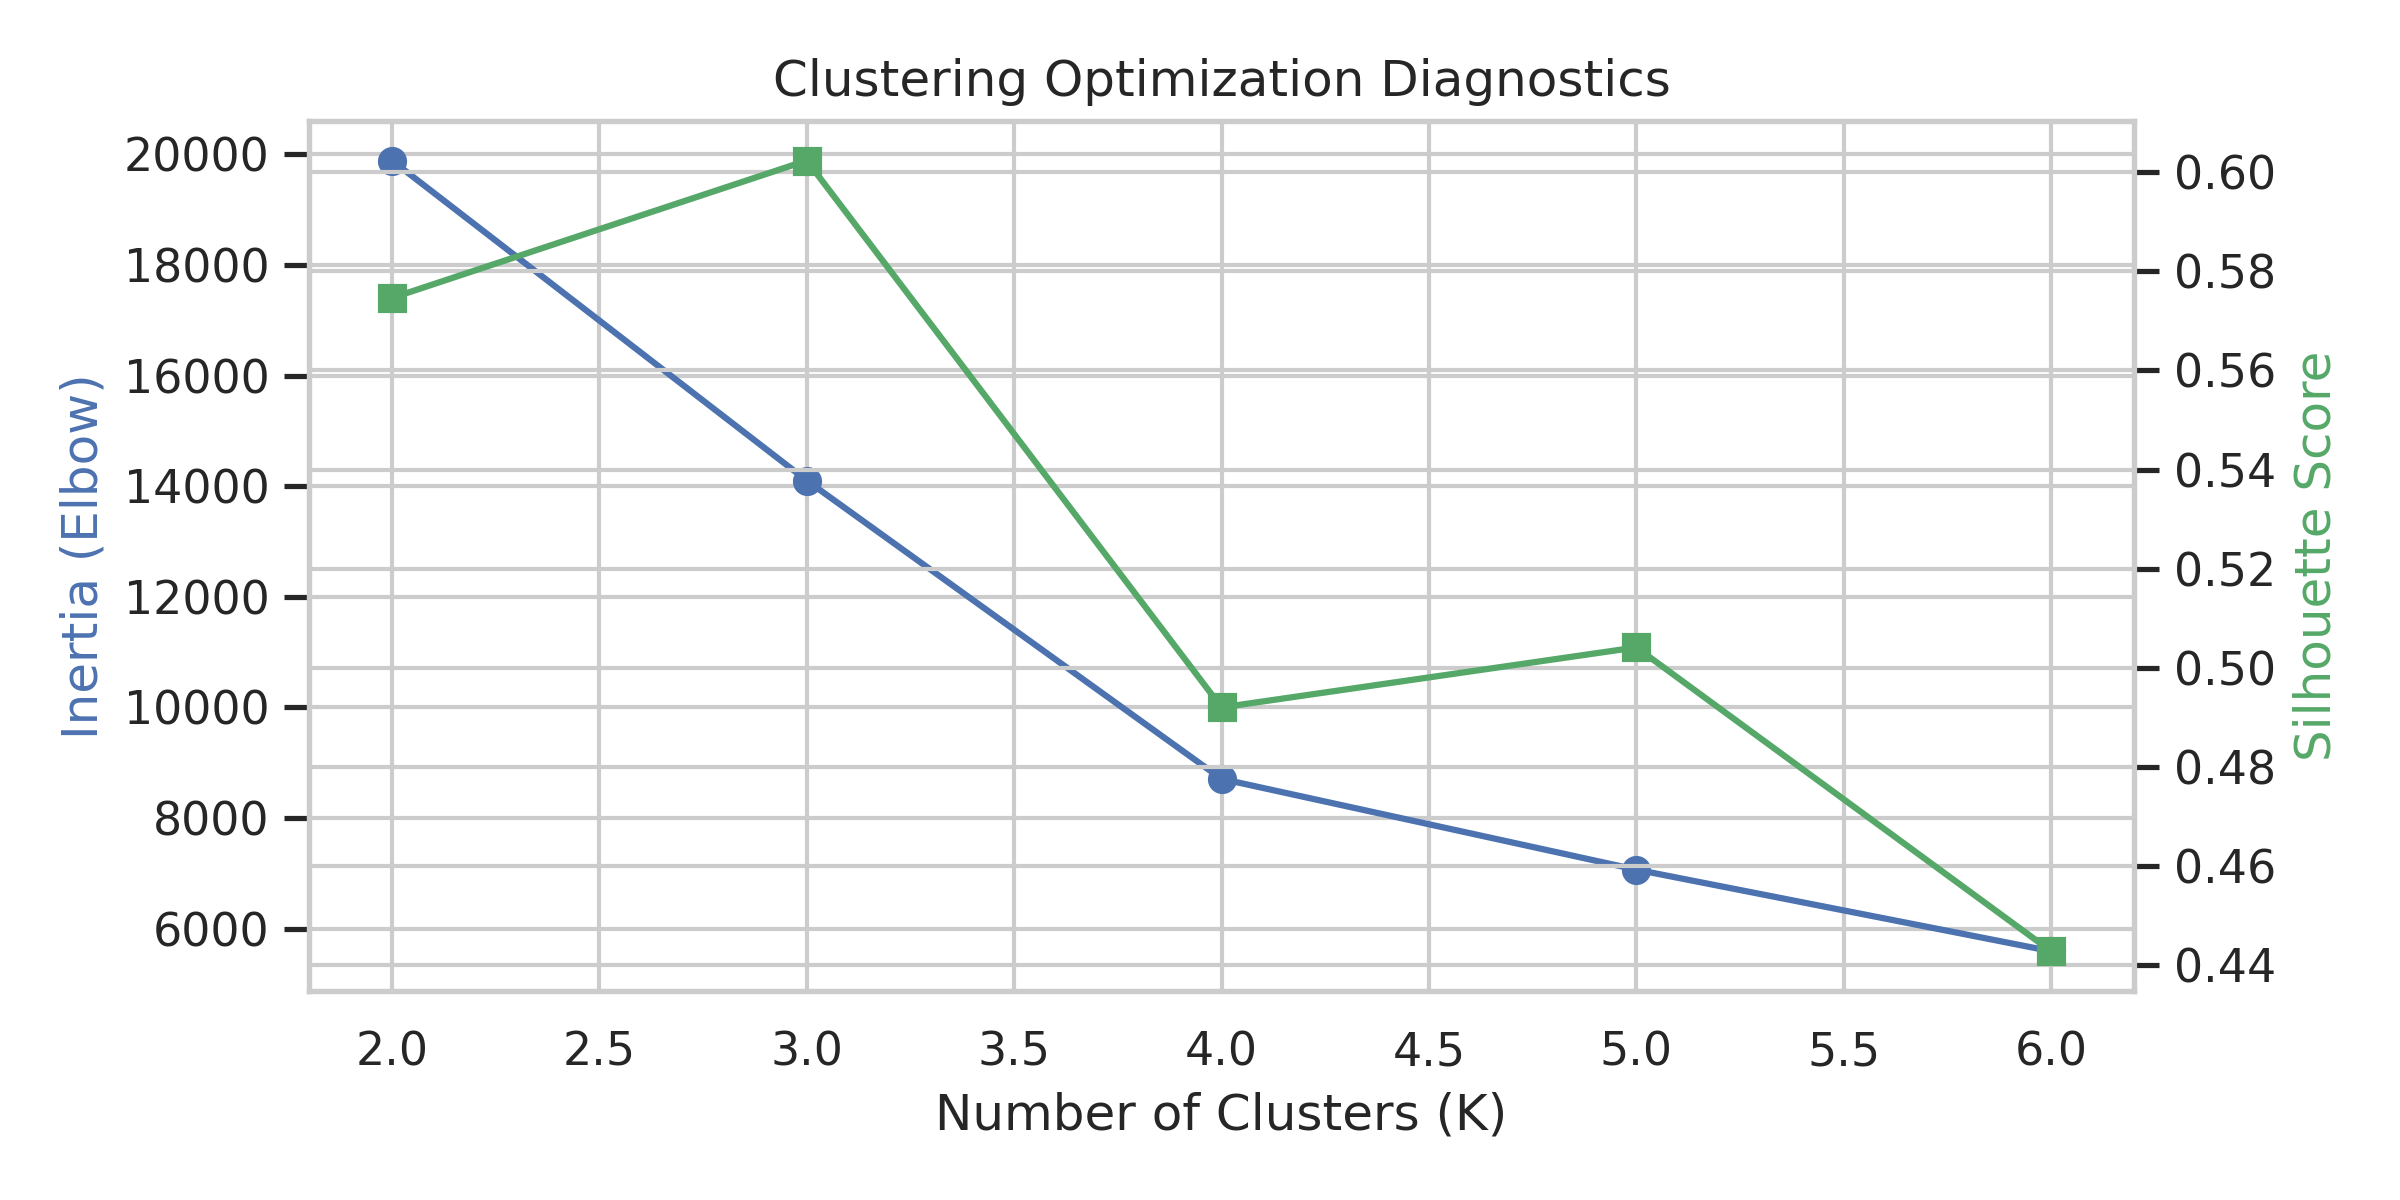

------------------------------------------------------------

🔹 Operational Matrix Visual Asset: PCA CLUSTER PROJECTION


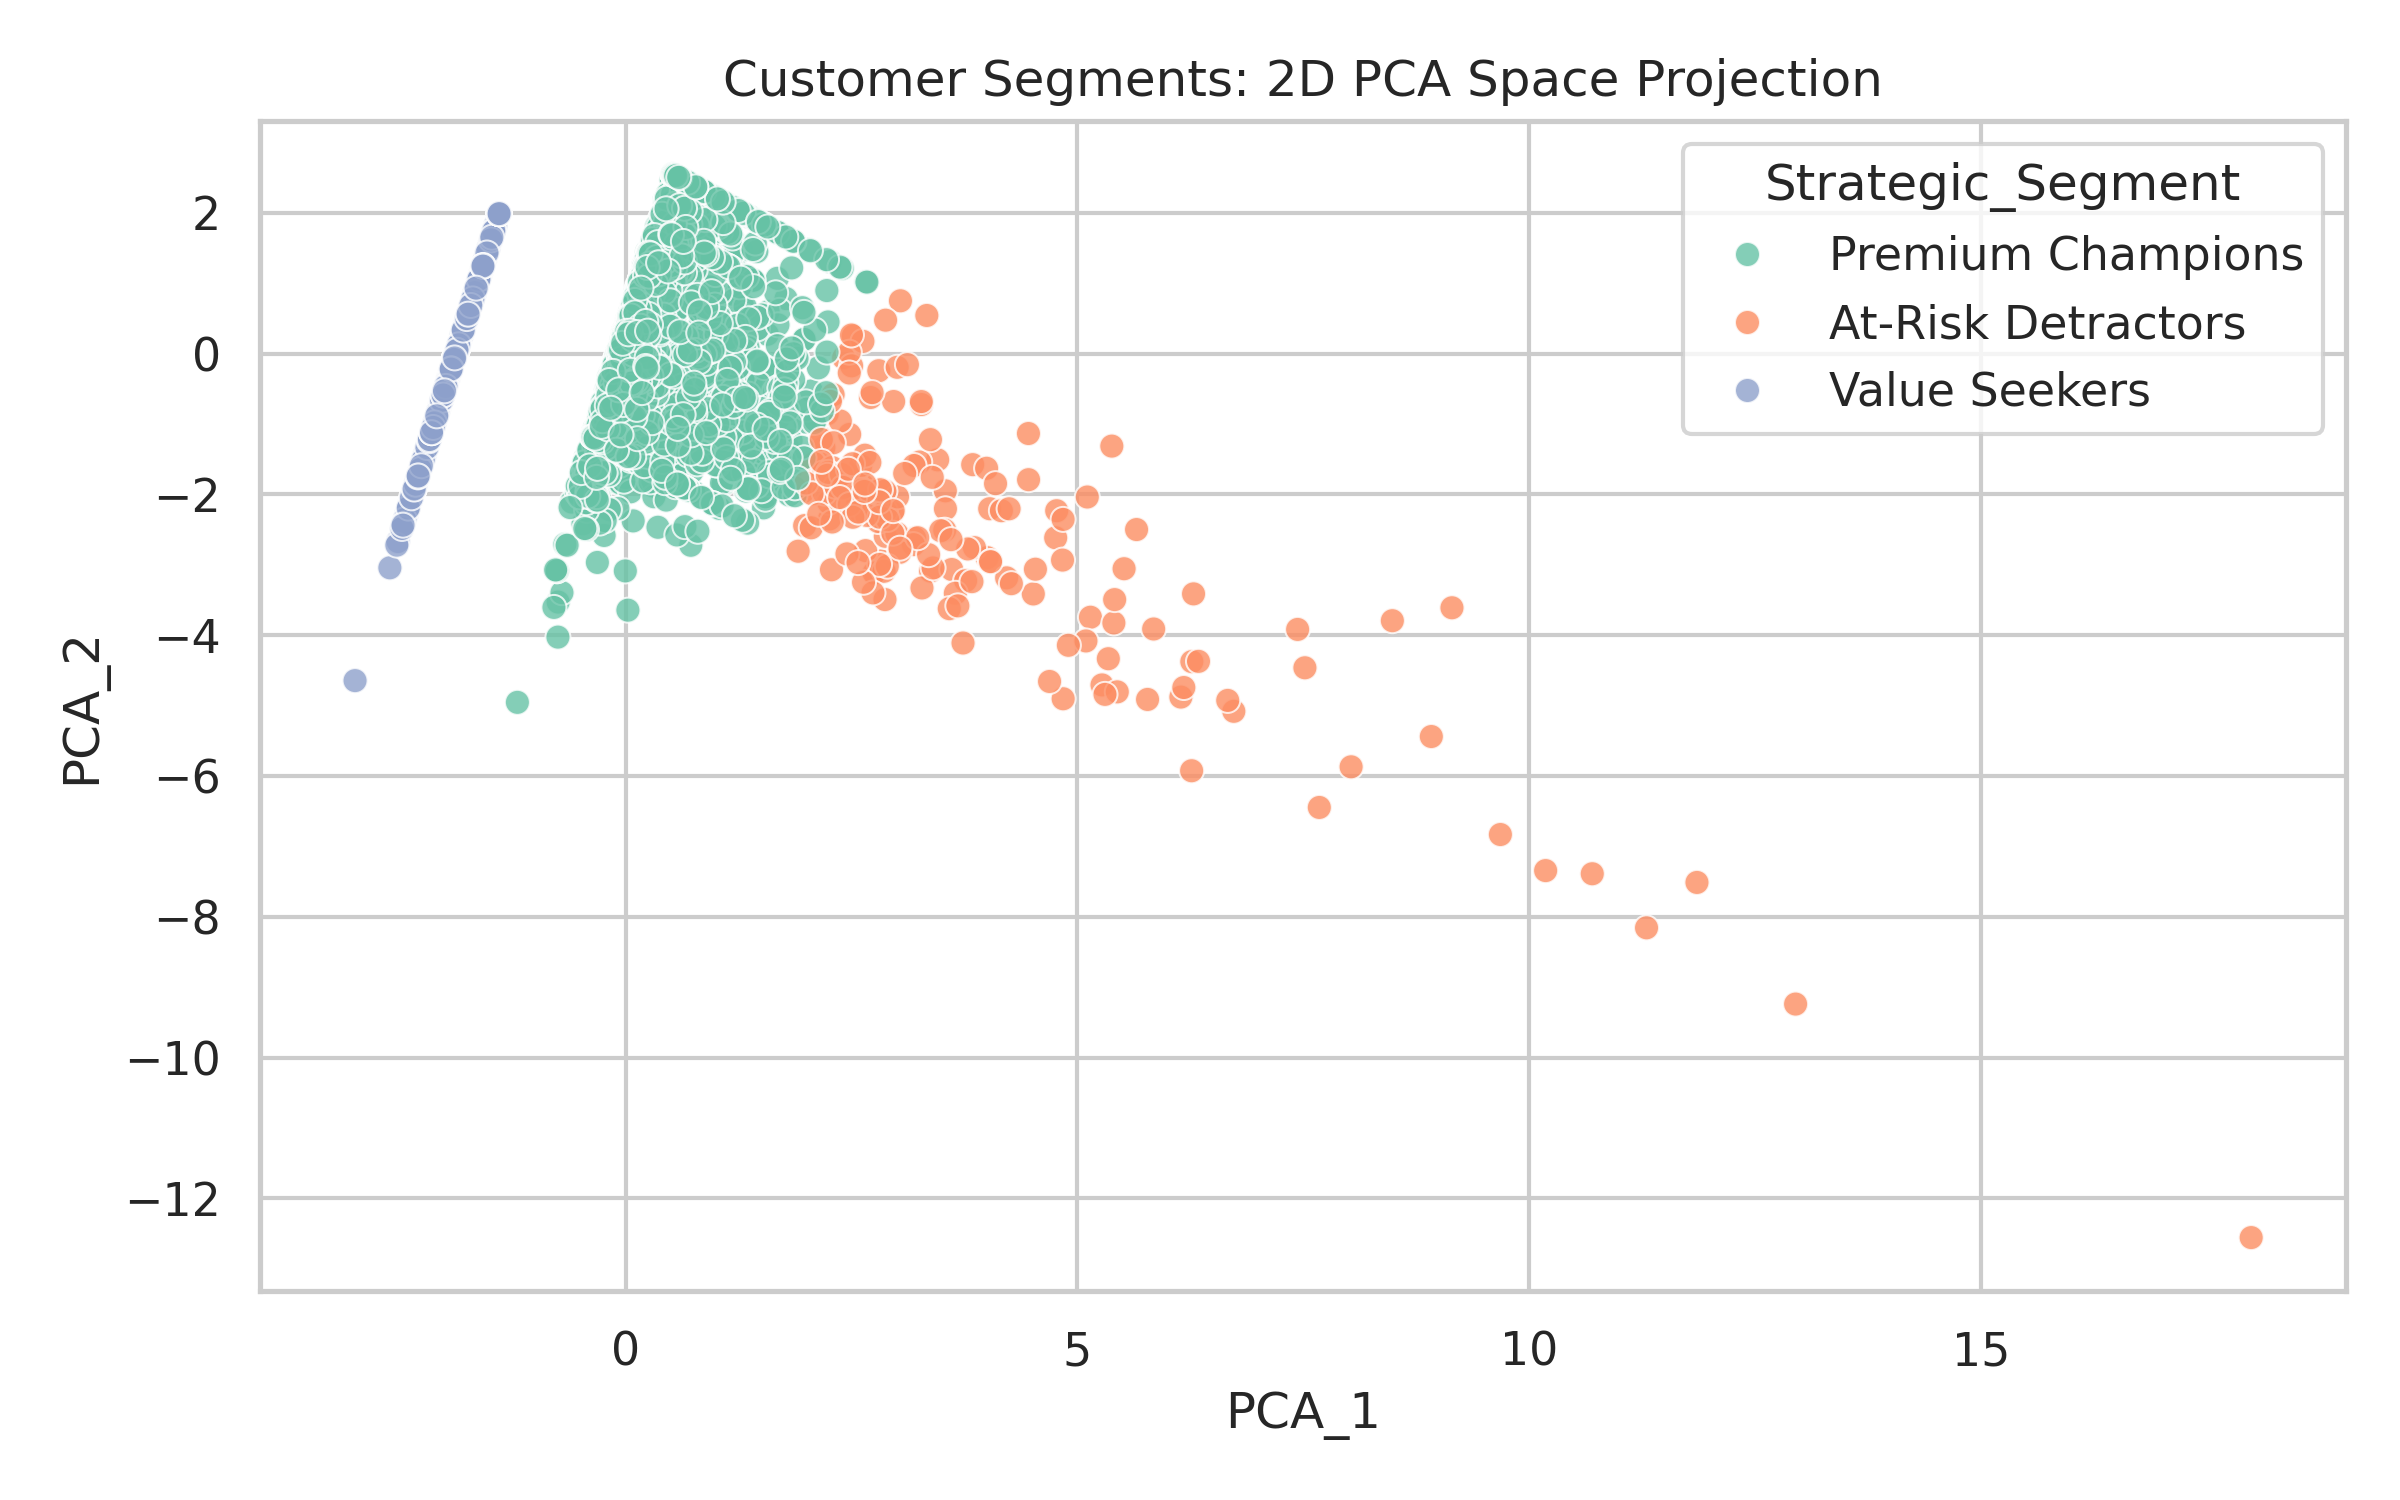

------------------------------------------------------------

🔹 Operational Matrix Visual Asset: STRATEGIC COHORT HEATMAP


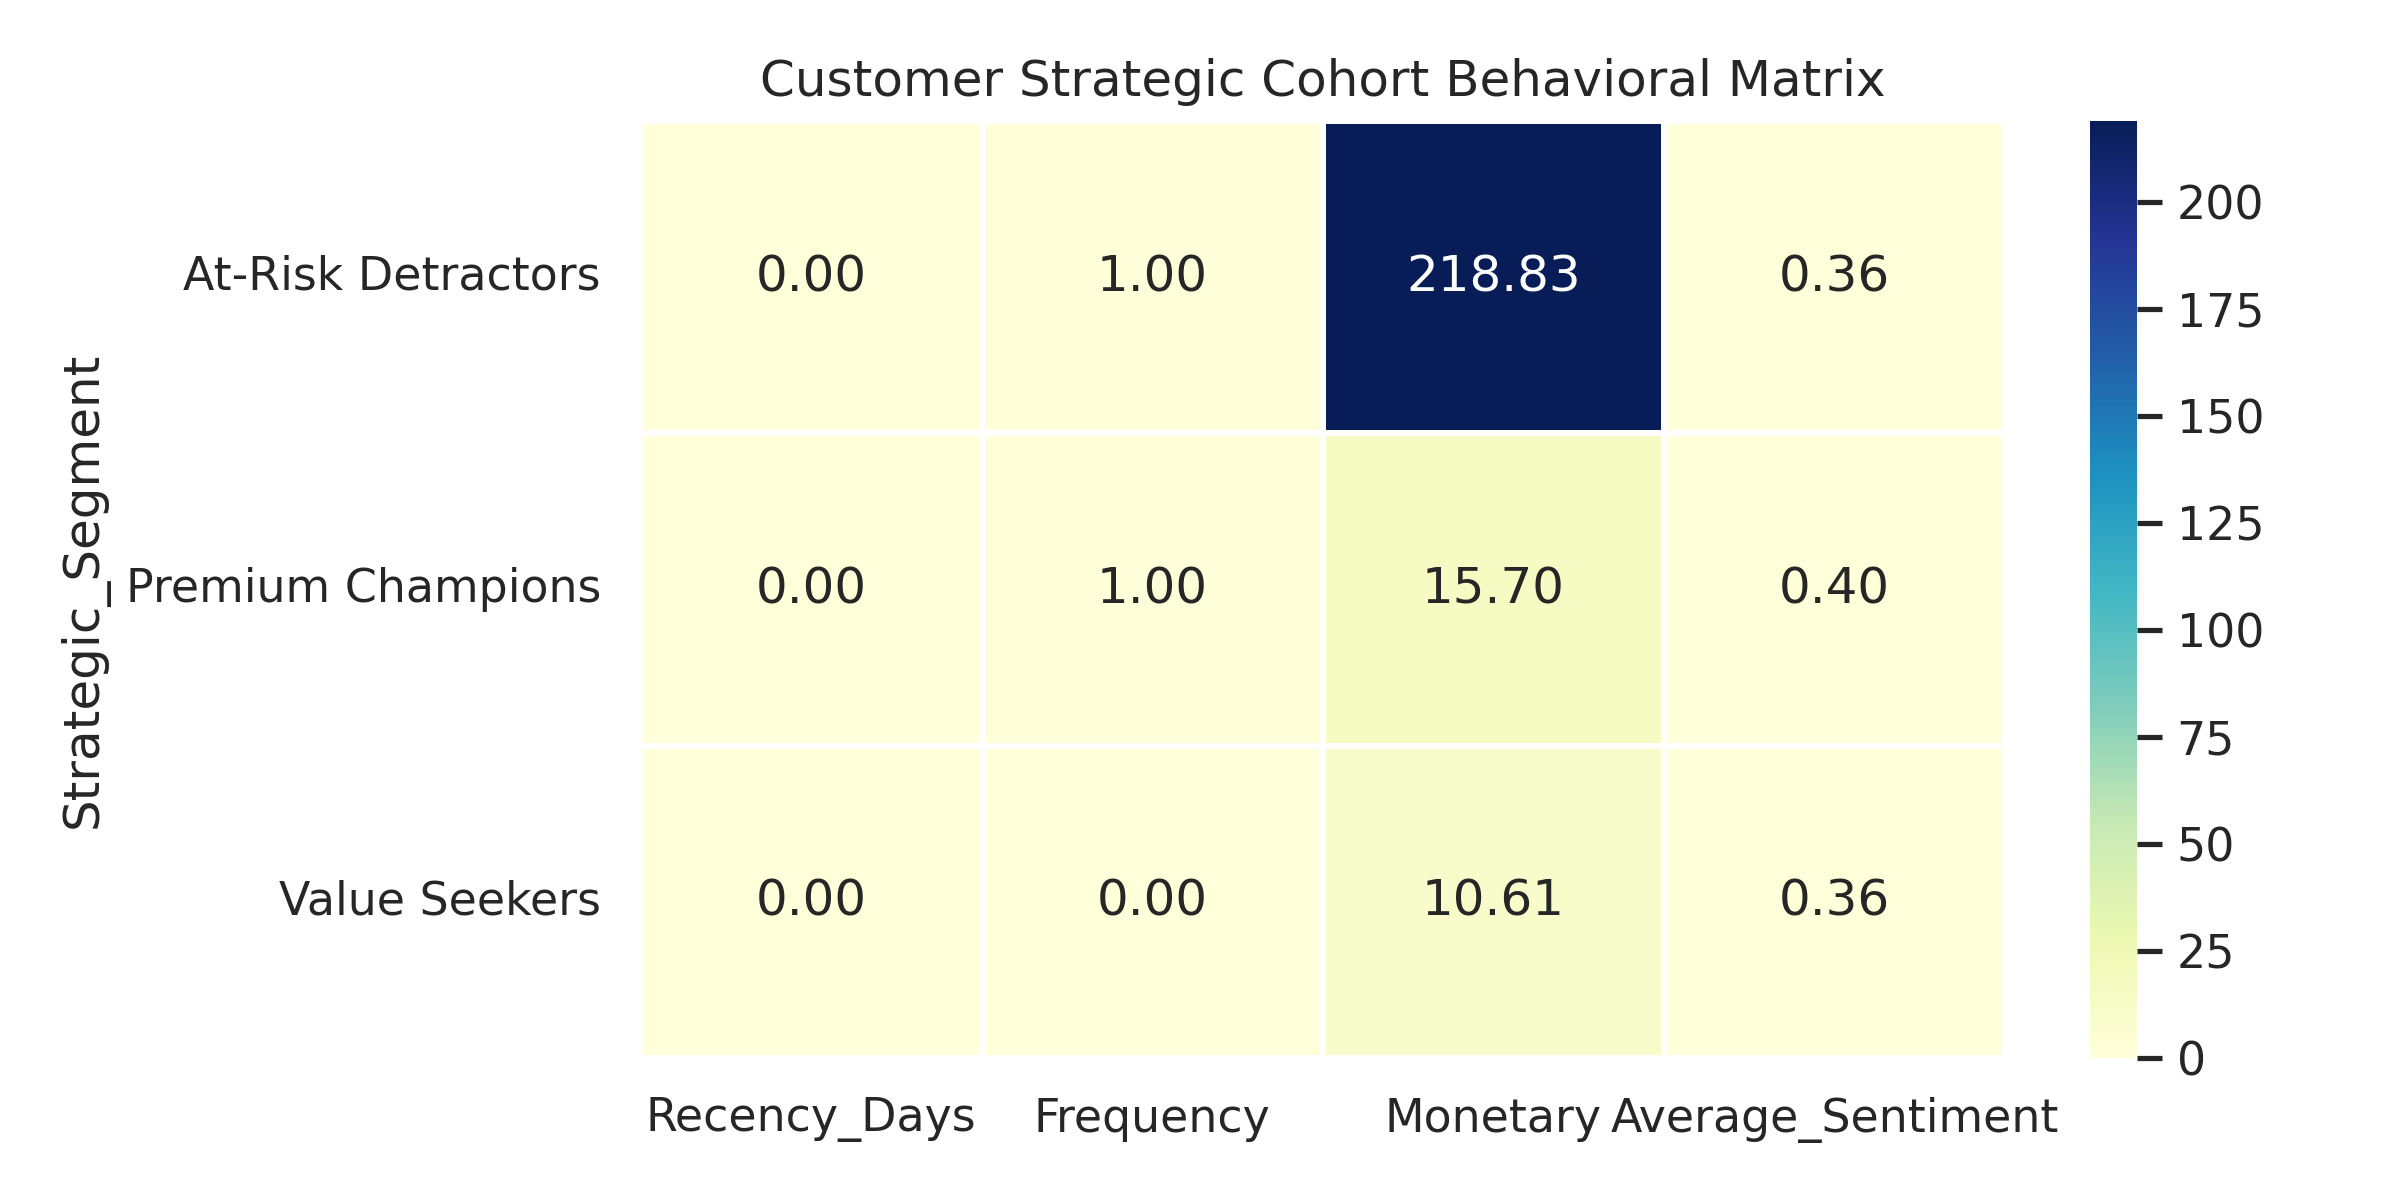

------------------------------------------------------------


In [7]:
from IPython.display import Image, display
import os

image_dir = "outputs/images/"
visual_assets = [
    "model_optimization_metrics.png",
    "pca_cluster_projection.png",
    "strategic_cohort_heatmap.png"
]

print("="*60)
print("📊 PORTFOLIO DISCOVERY ASSETS (RFM + SENTIMENT MODEL)")
print("="*60)

for asset in visual_assets:
    path = os.path.join(image_dir, asset)
    if os.path.exists(path):
        print(f"\n🔹 Operational Matrix Visual Asset: {asset.replace('_', ' ').replace('.png', '').upper()}")
        display(Image(filename=path, width=800))
        print("-" * 60)

In [8]:
app_content = """import streamlit as st
import pandas as pd
import os

st.set_page_config(page_title="Customer Intelligence Platform", layout="wide")

st.title("📊 Customer Segmentation & Intelligence Platform")
st.markdown("An RFM & NLP Sentiment-driven machine learning engine for customer behavioral cohort mapping.")

OUTPUT_PATH = "outputs/csv/segment_output.csv"
IMAGE_DIR = "outputs/images/"

if os.path.exists(OUTPUT_PATH):
    df = pd.read_csv(OUTPUT_PATH)

    st.subheader("📈 Platform KPIs")
    kpi1, kpi2, kpi3, kpi4 = st.columns(4)
    kpi1.metric("Total Profiled Accounts", f"{df['User_ID'].nunique():,}")
    kpi2.metric("Average Customer Value (Monetary)", f"${df['Monetary'].mean():,.2f}")
    kpi3.metric("Platform Purchase Frequency Count", f"{df['Frequency'].sum():,}")
    kpi4.metric("Net Sentiment Score Mean", f"{df['Average_Sentiment'].mean():+.2f}")

    st.subheader("🕵️ Cohort Discovery Insights")
    tab1, tab2 = st.tabs(["Strategic Cohort Matrix Heatmap", "Target Outreach List"])

    with tab1:
        heatmap_path = os.path.join(IMAGE_DIR, "strategic_cohort_heatmap.png")
        if os.path.exists(heatmap_path):
            st.image(heatmap_path, use_container_width=True)

    with tab2:
        if 'Strategic_Segment' in df.columns:
            target_list = df[df['Strategic_Segment'] == "At-Risk Detractors"][
                ['User_ID', 'Recency_Days', 'Frequency', 'Monetary', 'Average_Sentiment']
            ].sort_values(by="Monetary", ascending=False)
            st.dataframe(target_list, use_container_width=True)
else:
    st.warning("⚠️ No active dataset processing history found. Run the core pipeline first.")
"""

with open("app.py", "w") as f:
    f.write(app_content)
print("💾 Streamlit dashboard saved successfully to app.py!")

💾 Streamlit dashboard saved successfully to app.py!


In [12]:
import pandas as pd

# 1. Load the CSV while forcing Python to cleanly handle the messy quote breaks
df_fixed = pd.read_csv('/content/outputs/csv/segment_output.csv', on_bad_lines='skip')

# 2. Drop any completely empty rows that the broken formatting created
df_fixed = df_fixed.dropna(subset=['User_ID', 'Monetary'], how='all')

# 3. Save it to a perfectly structured Excel file
df_fixed.to_excel('segment_output_cleaned.xlsx', index=False)